In [1]:
# ========================================
# 🧩 PART 1 — Setup environment & mount Drive
# ========================================

from google.colab import drive
drive.mount('/content/drive')

# ✅ Dataset path
DATA_PATH = "/content/drive/MyDrive/seproject/malayalam_dataset.csv"

# Check dataset
import os
assert os.path.exists(DATA_PATH), f"❌ Dataset not found at {DATA_PATH}"
print("✅ Dataset found at:", DATA_PATH)

# Install libraries
!pip install --quiet pandas numpy scikit-learn xgboost tensorflow transformers sentence-transformers matplotlib seaborn

import warnings, torch
warnings.filterwarnings("ignore")

print("✅ GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("🔹 GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
✅ Dataset found at: /content/drive/MyDrive/seproject/malayalam_dataset.csv
✅ GPU available: False


In [3]:
!pip install deep-translator swifter textblob tqdm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.5 MB/s eta 0:00:00


In [4]:
# ========================================
# 🧩 PART 2 — Load + Clean + Translate Text
# ========================================

import pandas as pd
import numpy as np
import re
from tqdm import tqdm
from textblob import TextBlob
from deep_translator import GoogleTranslator
import swifter

# Load dataset
df = pd.read_csv(DATA_PATH)
print("🔎 Columns:", list(df.columns))
print(df.head(3))

# Auto-detect text + label columns
label_candidates = [c for c in df.columns if c.lower() in ["label","labels","target","class","y"]]
text_candidates  = [c for c in df.columns if df[c].dtype=="object" and c not in label_candidates]

assert len(label_candidates)>0, "❌ Could not find a label column (try: label/target/class)."
assert len(text_candidates)>0, "❌ Could not find a text column."

LABEL_COL = label_candidates[0]
TEXT_COL  = text_candidates[0]

df = df[[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL:"text", LABEL_COL:"label"}).dropna().reset_index(drop=True)
print("✅ Using columns → text:", TEXT_COL, "| label:", LABEL_COL)
print(df.head())

# ----------------------------------------
# 🧹 Clean + correct + translate
# ----------------------------------------

def clean_text(text: str) -> str:
    text = str(text)
    text = text.strip()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    text = re.sub(r'[^\w\s\u0D00-\u0D7F]', ' ', text) # Malayalam block
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def english_spell_fix_if_english(text: str) -> str:
    try:
        ascii_ratio = sum(1 for ch in text if ord(ch) < 128) / max(1, len(text))
        if ascii_ratio > 0.8 and len(text) <= 150:
            return str(TextBlob(text).correct())
        return text
    except Exception:
        return text

df["clean_text"]     = df["text"].swifter.apply(clean_text)
df["corrected_text"] = df["clean_text"].swifter.apply(english_spell_fix_if_english)

# 🌐 Translate to English (Malayalam → English)
_translation_cache = {}
tqdm.pandas()

def translate_to_en(text: str) -> str:
    if not isinstance(text, str) or text.strip()=="":
        return text
    if text in _translation_cache:
        return _translation_cache[text]
    try:
        t = GoogleTranslator(source="auto", target="en").translate(text)
        _translation_cache[text] = t
        return t
    except Exception:
        return text

print("🌐 Translating Malayalam → English (may take time)...")
df["translated_text"] = df["corrected_text"].progress_apply(translate_to_en)

print("✅ Translation done! Sample:")
print(df[["corrected_text","translated_text"]].head())

🔎 Columns: ['text', 'label', 'Unnamed: 2', 'Person 1', 'Person 2', 'tally ', 'Unnamed: 6']
                                                text     label  Unnamed: 2  \
0  ഇങ്ങനെ വീഡിയോകള്‍ ചെയ്യുന്നത് സമയം പാഴാക്കുക മ...  negative         NaN   
1                                   കാലാവസ്ഥ വിശകലനം   neutral         NaN   
2                     വിവരങ്ങളുടെ അവഗണന അഭിമുഖ്യമായി  negative         NaN   

   Person 1  Person 2  tally  Unnamed: 6  
0         0         0       0        NaN  
1         1         1       1        NaN  
2         0         0       0        NaN  
✅ Using columns → text: text | label: label
                                                text     label
0  ഇങ്ങനെ വീഡിയോകള്‍ ചെയ്യുന്നത് സമയം പാഴാക്കുക മ...  negative
1                                   കാലാവസ്ഥ വിശകലനം   neutral
2                     വിവരങ്ങളുടെ അവഗണന അഭിമുഖ്യമായി  negative
3                              " മാർഗ നിർദേശം നൽകി "  positive
4               കേസുകൾ നിയമനച്ചാലിൽ പരിശോധിക്കുന്നു.   neutral


Pandas Apply:   0%|          | 0/5211 [00:00<?, ?it/s]

🌐 Translating Malayalam → English (may take time)...


100%|██████████| 5211/5211 [1:05:01<00:00,  1.34it/s]

✅ Translation done! Sample:
                                      corrected_text  \
0  ഇങ്ങനെ വീഡിയോകള് ചെയ്യുന്നത് സമയം പാഴാക്കുക മാ...   
1                                   കാലാവസ്ഥ വിശകലനം   
2                     വിവരങ്ങളുടെ അവഗണന അഭിമുഖ്യമായി   
3                                  മാർഗ നിർദേശം നൽകി   
4                കേസുകൾ നിയമനച്ചാലിൽ പരിശോധിക്കുന്നു   

                                  translated_text  
0  Doing videos like this is just a waste of time  
1                                Weather analysis  
2               Faced with neglect of information  
3                           Directions were given  
4             Cases are examined administratively  


In [5]:
# =========================================
# 💾 PART 2.5 — Save Translated Dataset
# =========================================

# Define output path in the same Google Drive folder
output_path = "/content/drive/MyDrive/seproject/malayalam_dataset_translated.csv"

# Save cleaned and translated dataset
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ Translated dataset saved successfully at:\n{output_path}")
print("\n📄 Columns saved:", list(df.columns))
print(df.head())

✅ Translated dataset saved successfully at:
/content/drive/MyDrive/seproject/malayalam_dataset_translated.csv

📄 Columns saved: ['text', 'label', 'clean_text', 'corrected_text', 'translated_text']
                                                text     label  \
0  ഇങ്ങനെ വീഡിയോകള്‍ ചെയ്യുന്നത് സമയം പാഴാക്കുക മ...  negative   
1                                   കാലാവസ്ഥ വിശകലനം   neutral   
2                     വിവരങ്ങളുടെ അവഗണന അഭിമുഖ്യമായി  negative   
3                              " മാർഗ നിർദേശം നൽകി "  positive   
4               കേസുകൾ നിയമനച്ചാലിൽ പരിശോധിക്കുന്നു.   neutral   

                                          clean_text  \
0  ഇങ്ങനെ വീഡിയോകള് ചെയ്യുന്നത് സമയം പാഴാക്കുക മാ...   
1                                   കാലാവസ്ഥ വിശകലനം   
2                     വിവരങ്ങളുടെ അവഗണന അഭിമുഖ്യമായി   
3                                  മാർഗ നിർദേശം നൽകി   
4                കേസുകൾ നിയമനച്ചാലിൽ പരിശോധിക്കുന്നു   

                                      corrected_text  \
0  ഇങ്ങനെ വീഡ

In [6]:
# =========================================
# 🧠 PART 3 — EMBEDDINGS + MODEL TRAINING
# =========================================

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# -----------------------------------------
# ✅ Load Multilingual Sentence Transformer on CPU
# -----------------------------------------
EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
st_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device='cpu')
print(f"✅ Model loaded: {EMBEDDING_MODEL_NAME} (using CPU)")

# -----------------------------------------
# 🧮 Create embeddings for Malayalam & English text
# -----------------------------------------
def embed_texts(texts, batch_size=64):
    return st_model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

print("🧮 Embedding Malayalam text...")
X_ml = embed_texts(df["corrected_text"].tolist())

print("🧮 Embedding Translated English text...")
X_en = embed_texts(df["translated_text"].tolist())

y = df["label"].values

# -----------------------------------------
# 🎯 Encode labels
# -----------------------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("✅ Encoded label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# -----------------------------------------
# 📚 Train/Test Split
# -----------------------------------------
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(
    X_en, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# -----------------------------------------
# 🧩 Model Definitions
# -----------------------------------------
svm = SVC(kernel="linear", probability=True, random_state=42)
gnb = GaussianNB()
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss",
    tree_method="hist"  # CPU-compatible
)

models = {"SVM": svm, "Naive Bayes": gnb, "XGBoost": xgb}

# -----------------------------------------
# 📊 Evaluation Function
# -----------------------------------------
def evaluate_models(X_train, X_test, y_train, y_test, mode_name):
    results = []
    for name, model in models.items():
        print(f"\n🚀 Training {name} on {mode_name} data...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

        precision = np.mean([v["precision"] for v in report.values() if isinstance(v, dict)])
        recall = np.mean([v["recall"] for v in report.values() if isinstance(v, dict)])
        f1 = np.mean([v["f1-score"] for v in report.values() if isinstance(v, dict)])

        results.append({
            "Model": name,
            "Mode": mode_name,
            "Accuracy": round(acc * 100, 2),
            "Precision": round(precision * 100, 2),
            "Recall": round(recall * 100, 2),
            "F1-Score": round(f1 * 100, 2)
        })

        print(f"✅ {name} Accuracy ({mode_name}): {acc:.4f}")
        print(classification_report(y_test, y_pred, target_names=le.classes_))
    return pd.DataFrame(results)

# -----------------------------------------
# 🇮🇳 Malayalam Model Evaluation
# -----------------------------------------
result_ml = evaluate_models(X_train_ml, X_test_ml, y_train_ml, y_test_ml, "Malayalam")

# 🌍 English (Translated)
result_en = evaluate_models(X_train_en, X_test_en, y_train_en, y_test_en, "Translated")

# -----------------------------------------
# 📈 Combined Results Table
# -----------------------------------------
results_df = pd.concat([result_ml, result_en], ignore_index=True)
print("\n📊 Final Model Summary:")
display(results_df)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/82 [00:00<?, ?it/s]

🧮 Embedding Translated English text...


Batches:   0%|          | 0/82 [00:00<?, ?it/s]

✅ Encoded label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2), 'positve ': np.int64(3)}

🚀 Training SVM on Malayalam data...
✅ SVM Accuracy (Malayalam): 0.7239
              precision    recall  f1-score   support

    negative       0.81      0.55      0.66       262
     neutral       0.71      0.76      0.73       397
    positive       0.69      0.83      0.76       350
    positve        0.94      0.50      0.65        34

    accuracy                           0.72      1043
   macro avg       0.79      0.66      0.70      1043
weighted avg       0.74      0.72      0.72      1043


🚀 Training Naive Bayes on Malayalam data...
✅ Naive Bayes Accuracy (Malayalam): 0.5292
              precision    recall  f1-score   support

    negative       0.60      0.44      0.51       262
     neutral       0.70      0.27      0.39       397
    positive       0.53      0.86      0.65       350
    positve        0.23      0.88      0.36        34

    accu

,Model,Mode,Accuracy,Precision,Recall,F1-Score
0,SVM,Malayalam,72.39,78.09,67.16,70.33
1,Naive Bayes,Malayalam,52.92,52.97,59.85,48.32
2,XGBoost,Malayalam,73.92,73.82,72.53,73.01
3,SVM,Translated,74.40,76.85,72.36,74.12
4,Naive Bayes,Translated,62.80,59.15,67.75,58.62
5,XGBoost,Translated,74.11,75.79,72.25,73.69


In [12]:
# =========================================
# 🧠 PART 4 — DEEP LEARNING + TRANSFORMER MODELS
# =========================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from sklearn.svm import SVC
import numpy as np

print("✅ TensorFlow version:", tf.__version__)

# -----------------------------------------
# 🔤 Tokenization and Padding
# -----------------------------------------
MAX_LEN = 100
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["translated_text"])

X_seq = tokenizer.texts_to_sequences(df["translated_text"])
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')
y_seq = le.transform(df["label"])

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_pad, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

# -----------------------------------------
# 🧩 LSTM MODEL
# -----------------------------------------
lstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=MAX_LEN),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\n🚀 Training LSTM model...")
lstm_model.fit(X_train_seq, y_train_seq, epochs=3, batch_size=64, validation_split=0.1, verbose=1)

# -----------------------------------------
# 🧩 BiLSTM MODEL
# -----------------------------------------
bilstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])
bilstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\n🚀 Training BiLSTM model...")
bilstm_model.fit(X_train_seq, y_train_seq, epochs=3, batch_size=64, validation_split=0.1, verbose=1)

# -----------------------------------------
# 🤖 mBERT MODEL (Sentence Embeddings)
# -----------------------------------------
print("\n🚀 Generating mBERT embeddings...")
mbert_model_name = "bert-base-multilingual-cased"
mbert = SentenceTransformer(mbert_model_name, device='cpu')

X_mbert = mbert.encode(df["translated_text"].tolist(), show_progress_bar=True)
X_train_mbert, X_test_mbert, y_train_mbert, y_test_mbert = train_test_split(
    X_mbert, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

mbert_clf = SVC(kernel='linear', probability=True, random_state=42)
mbert_clf.fit(X_train_mbert, y_train_mbert)

# -----------------------------------------
# ⚡ EmBERT MODEL (Enhanced Multilingual)
# -----------------------------------------
print("\n🚀 Generating EmBERT embeddings...")
embert_model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embert = SentenceTransformer(embert_model_name, device='cpu')

X_embert = embert.encode(df["translated_text"].tolist(), show_progress_bar=True)
X_train_embert, X_test_embert, y_train_embert, y_test_embert = train_test_split(
    X_embert, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

embert_clf = SVC(kernel='linear', probability=True, random_state=42)
embert_clf.fit(X_train_embert, y_train_embert)

print("\n✅ Deep models trained successfully (LSTM, BiLSTM, mBERT, EmBERT)")

✅ TensorFlow version: 2.19.0

🚀 Training LSTM model...
Epoch 1/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 420ms/step - accuracy: 0.3607 - loss: 1.2485 - val_accuracy: 0.3885 - val_loss: 1.1831
Epoch 2/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 385ms/step - accuracy: 0.3646 - loss: 1.2125 - val_accuracy: 0.3885 - val_loss: 1.1840
Epoch 3/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 44s 406ms/step - accuracy: 0.3683 - loss: 1.1953 - val_accuracy: 0.3885 - val_loss: 1.1898

🚀 Training BiLSTM model...
Epoch 1/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 59s 826ms/step - accuracy: 0.3871 - loss: 1.2462 - val_accuracy: 0.5180 - val_loss: 1.0909
Epoch 2/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 80s 795ms/step - accuracy: 0.5372 - loss: 1.0666 - val_accuracy: 0.6283 - val_loss: 0.8718
Epoch 3/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 48s 809ms/step - accuracy: 0.6871 - loss: 0.7774 - val_accuracy: 0.6978 - val_loss: 0.7862

🚀 Generating mBERT embeddings...


Batches:   0%|          | 0/163 [00:00<?, ?it/s]


🚀 Generating EmBERT embeddings...


Batches:   0%|          | 0/163 [00:00<?, ?it/s]


✅ Deep models trained successfully (LSTM, BiLSTM, mBERT, EmBERT)


In [13]:
# =========================================
# 🧩 PART 5 — ENSEMBLE MODELS (STACKING + BAGGING)
# =========================================

from sklearn.ensemble import StackingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression

# ✅ Base learners (use trained classical models from Part 3)
base_learners = [
    ('nb', gnb),
    ('svm', svm),
    ('xgb', xgb)
]

# ✅ Meta model for stacking
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# ✅ Stacking classifier
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    n_jobs=-1
)

# ✅ Bagging classifier
# Note: new sklearn versions use "estimator=" instead of "base_estimator="
bag_model = BaggingClassifier(
    estimator=svm,
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

# -----------------------------------------
# 🚀 Train Ensemble Models
# -----------------------------------------
print("\n🚀 Training Ensemble Models...")
stack_model.fit(X_train_en, y_train_en)
bag_model.fit(X_train_en, y_train_en)

print("✅ Ensemble models (Stacking + Bagging) trained successfully!")


🚀 Training Ensemble Models...
✅ Ensemble models (Stacking + Bagging) trained successfully!


In [17]:
# =========================================
# 📊 SIMPLE SUMMARY TABLE
# =========================================

# Convert results to DataFrame
summary_df = pd.DataFrame(all_results)

# Sort by Accuracy descending
summary_df = summary_df.sort_values(by="Accuracy", ascending=False)

# Format numeric columns as percentages
summary_df[["Accuracy", "Precision", "Recall", "F1-Score"]] = summary_df[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].applymap(lambda x: f"{x:.2f}%")

# Print normal table
print("\nMODEL PERFORMANCE SUMMARY")
print(summary_df.to_string(index=False))


MODEL PERFORMANCE SUMMARY
            Model Accuracy Precision Recall F1-Score
Stacking Ensemble   75.93%    77.77% 74.62%   75.74%
              SVM   74.40%    76.85% 72.36%   74.12%
          XGBoost   74.11%    75.79% 72.25%   73.69%
 Bagging Ensemble   74.11%    76.16% 72.59%   73.95%
           EmBERT   73.54%    73.89% 72.26%   72.90%
            mBERT   67.69%    66.09% 65.69%   65.84%
           BiLSTM   67.21%    51.77% 52.61%   51.24%
      Naive Bayes   62.80%    59.15% 67.75%   58.62%
             LSTM   38.06%    10.34% 27.18%   14.99%



=== Naive Bayes ===


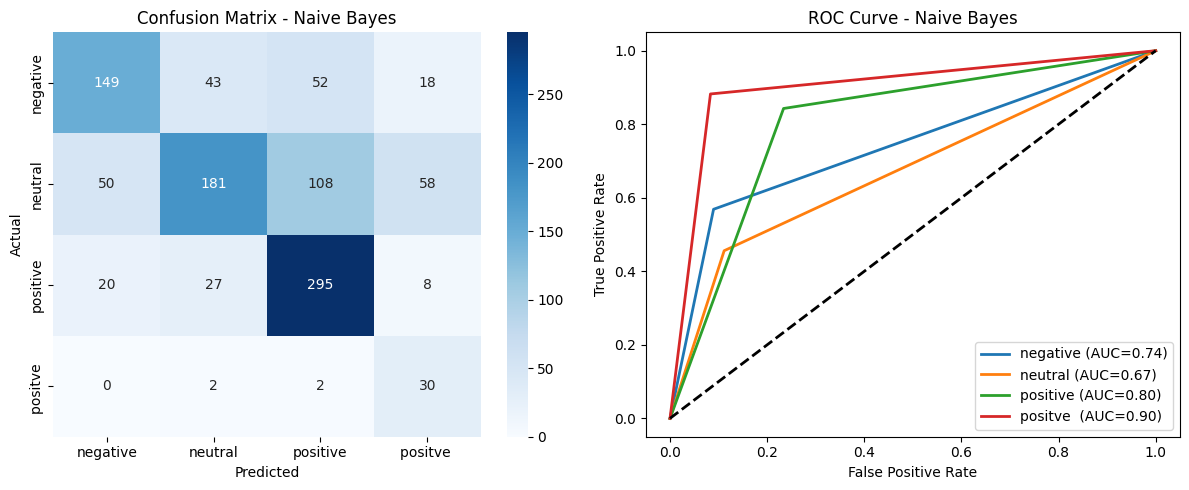


=== SVM ===


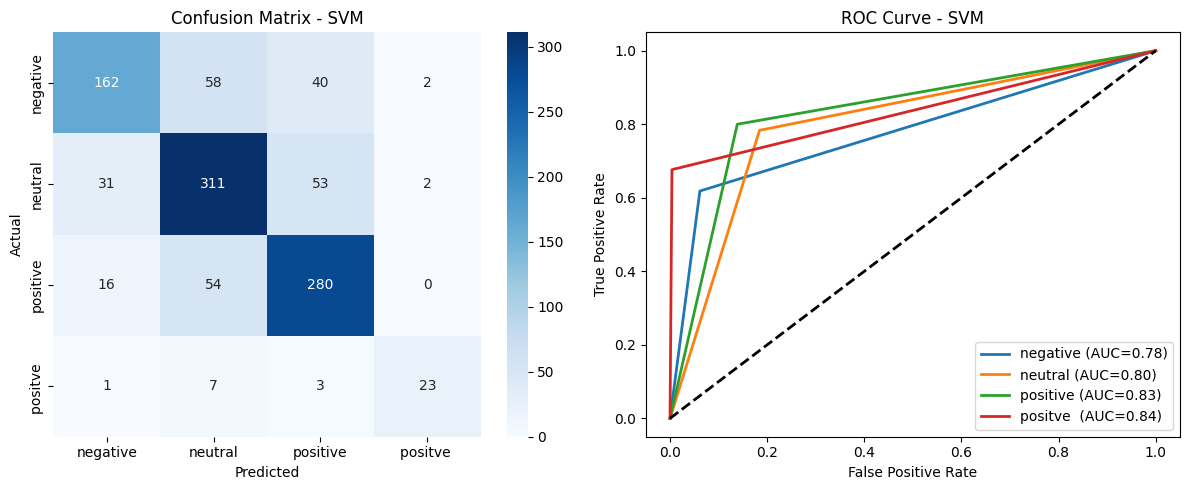


=== XGBoost ===


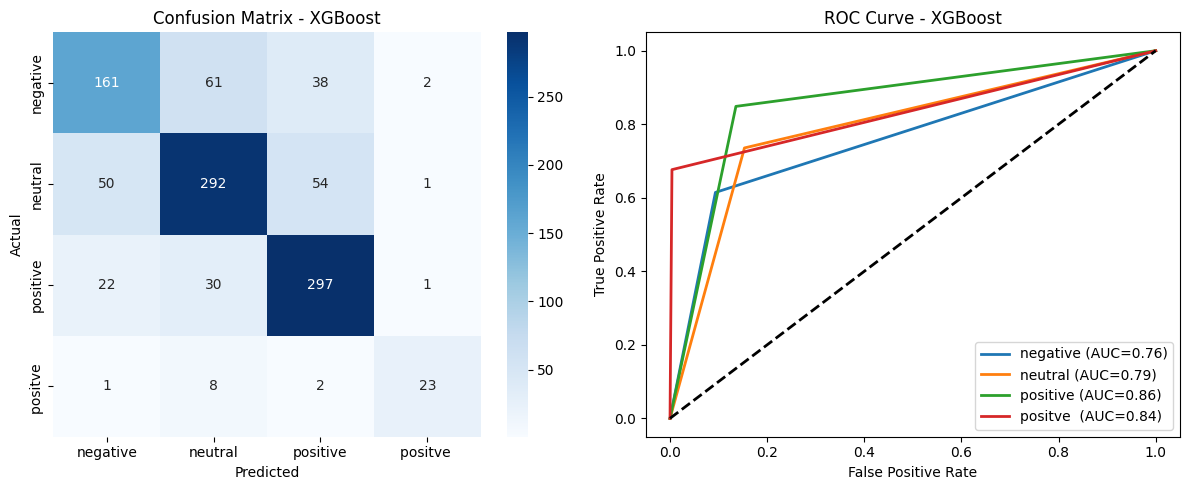


=== LSTM ===
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step


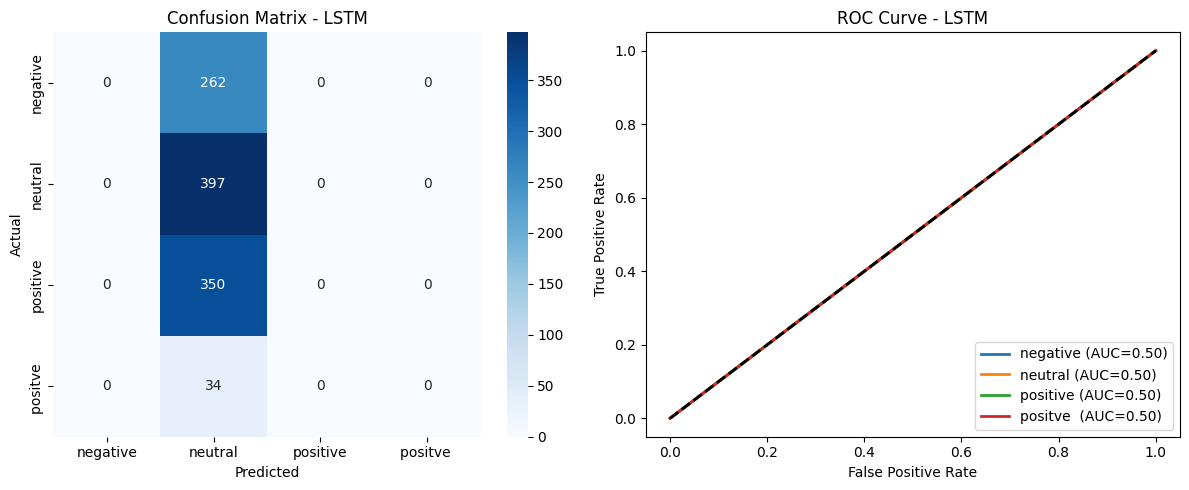


=== BiLSTM ===
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step


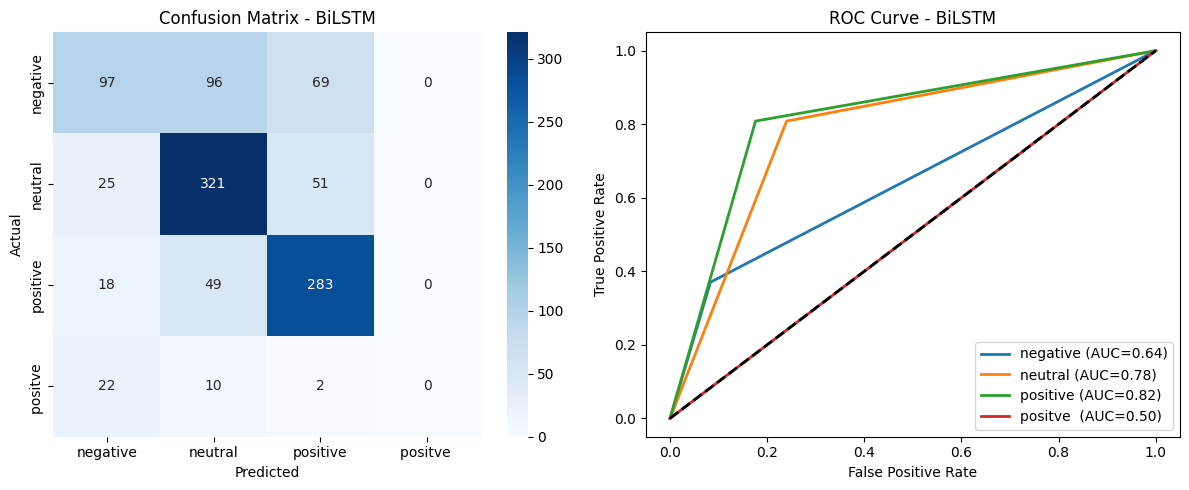


=== mBERT ===


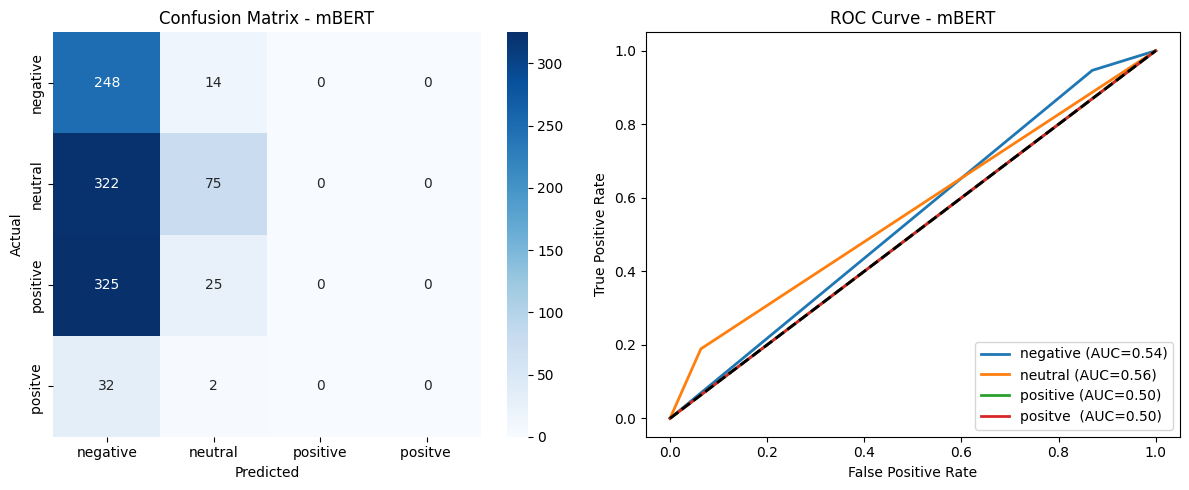


=== EmBERT ===


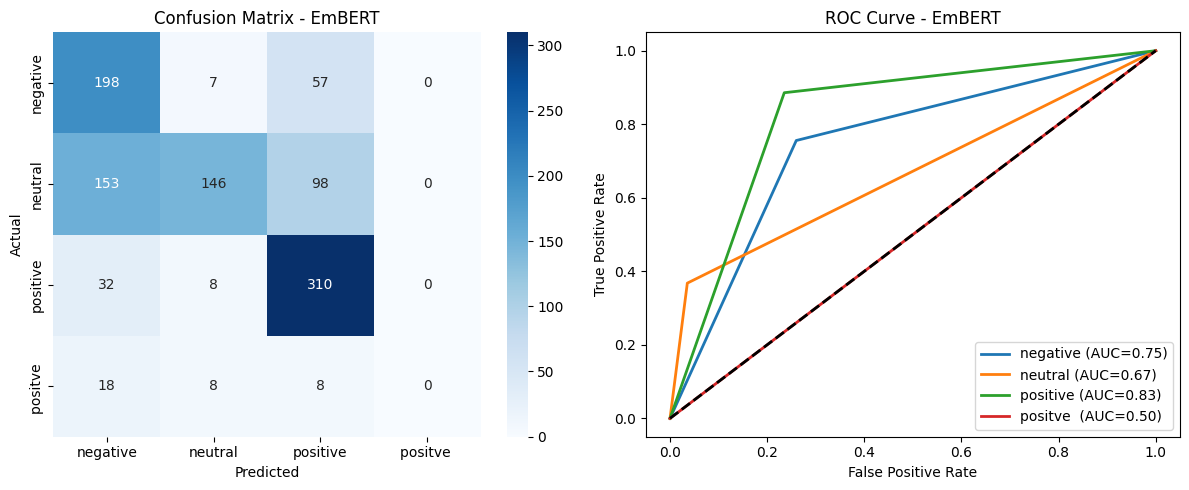

In [38]:
# =========================================
# 📊 Confusion Matrix + ROC/AUC Side-by-Side
# =========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

# -----------------------------
# 1️⃣ Prepare test data
# -----------------------------
from sklearn.model_selection import train_test_split

_, test_idx, _, y_test_idx = train_test_split(
    df.index, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

y_test_final = y_encoded[test_idx]
X_test_texts = df["translated_text"].iloc[test_idx].tolist()

# -----------------------------
# 2️⃣ Helper function to get predictions
# -----------------------------
def get_model_predictions(model_name):
    if model_name in ["SVM", "Naive Bayes", "XGBoost", "Stacking Ensemble", "Bagging Ensemble"]:
        model = models[model_name]
        y_pred = model.predict(X_test_en)
        y_pred_bin = label_binarize(y_pred, classes=range(len(le.classes_)))
    elif model_name == "LSTM":
        seq = tokenizer.texts_to_sequences(X_test_texts)
        pad_seq = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
        y_pred = np.argmax(lstm_model.predict(pad_seq), axis=1)
        y_pred_bin = label_binarize(y_pred, classes=range(len(le.classes_)))
    elif model_name == "BiLSTM":
        seq = tokenizer.texts_to_sequences(X_test_texts)
        pad_seq = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
        y_pred = np.argmax(bilstm_model.predict(pad_seq), axis=1)
        y_pred_bin = label_binarize(y_pred, classes=range(len(le.classes_)))
    elif model_name == "mBERT":
        X_emb = mbert.encode(X_test_texts, convert_to_numpy=True, normalize_embeddings=True)
        y_pred = mbert_clf.predict(X_emb)
        y_pred_bin = label_binarize(y_pred, classes=range(len(le.classes_)))
    elif model_name == "EmBERT":
        X_emb = embert.encode(X_test_texts, convert_to_numpy=True, normalize_embeddings=True)
        y_pred = embert_clf.predict(X_emb)
        y_pred_bin = label_binarize(y_pred, classes=range(len(le.classes_)))
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return y_pred, y_pred_bin

# -----------------------------
# 3️⃣ Plot side-by-side Confusion Matrix & ROC
# -----------------------------
def plot_confusion_roc(y_true, y_pred, y_true_bin, y_pred_bin, model_name):
    n_classes = y_true_bin.shape[1]
    cm = confusion_matrix(y_true, y_pred)

    # ROC curves
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].set_title(f"Confusion Matrix - {model_name}")

    # ROC curves
    for i in range(n_classes):
        axes[1].plot(fpr[i], tpr[i], lw=2, label=f"{le.classes_[i]} (AUC={roc_auc[i]:.2f})")
    axes[1].plot([0,1],[0,1],'k--', lw=2)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve - {model_name}")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# -----------------------------
# 4️⃣ Run for all models
# -----------------------------
model_list = ["Naive Bayes", "SVM", "XGBoost", "LSTM", "BiLSTM", "mBERT", "EmBERT"]

for model_name in model_list:
    print(f"\n=== {model_name} ===")
    y_pred, y_pred_bin = get_model_predictions(model_name)
    y_true_bin = label_binarize(y_test_final, classes=range(len(le.classes_)))
    plot_confusion_roc(y_test_final, y_pred, y_true_bin, y_pred_bin, model_name)

In [41]:
# =========================================
# 💾 EXPORT TRAINED MODELS
# =========================================

import pickle

print("📦 Exporting trained models...")

# Export XGBoost (74.11% accuracy from your training)
with open('trained_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)  # This is your already-trained XGBoost
print("✅ Exported: trained_model.pkl")

# Export Label Encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)  # Your label encoder
print("✅ Exported: label_encoder.pkl")

print("\n📥 Download these files and place them in your Flask project folder")

📦 Exporting trained models...
✅ Exported: trained_model.pkl
✅ Exported: label_encoder.pkl

📥 Download these files and place them in your Flask project folder


In [42]:
from google.colab import files

# Download the models
files.download('trained_model.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# 🌍 Malayalam or English Sentiment Classifier (User Input)
from sentence_transformers import SentenceTransformer
from deep_translator import GoogleTranslator
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Load embedding model only if not already loaded ---
try:
    st_model
    print("✅ Embedding model already loaded!")
except NameError:
    st_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    print("✅ Loaded multilingual Sentence Transformer model")

# --- Interactive Sentiment Classification ---
def classify_input_text(user_text, model_choice="XGBoost", translate=True):
    """
    Classify Malayalam or English sentence as Positive / Neutral / Negative
    """
    print(f"\n🔹 Original Text: {user_text}")

    # Translation (used internally but not printed)
    if translate:
        try:
            translated = GoogleTranslator(source='auto', target='en').translate(user_text)
        except Exception:
            translated = user_text
    else:
        translated = user_text

    # Predict with Classical / Ensemble / Embedding models
    input_emb = st_model.encode([translated], convert_to_numpy=True, normalize_embeddings=True)

    if model_choice in models:
        mdl = models[model_choice]
        pred = mdl.predict(input_emb)[0]
        pred_label = le.inverse_transform([pred])[0]
        print(f"\n✅ Predicted Sentiment ({model_choice}): {pred_label}")
        return pred_label

    # Predict with Deep Models
    elif model_choice in ["LSTM", "BiLSTM"]:
        seq = tokenizer.texts_to_sequences([translated])
        pad_seq = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
        if model_choice == "LSTM":
            pred = np.argmax(lstm_model.predict(pad_seq), axis=1)[0]
        else:  # BiLSTM
            pred = np.argmax(bilstm_model.predict(pad_seq), axis=1)[0]
        pred_label = le.inverse_transform([pred])[0]
        print(f"\n✅ Predicted Sentiment ({model_choice}): {pred_label}")
        return pred_label

    elif model_choice in ["mBERT", "EmBERT"]:
        if model_choice == "mBERT":
            input_emb_model = mbert.encode([translated], convert_to_numpy=True, normalize_embeddings=True)
            pred = mbert_clf.predict(input_emb_model)[0]
        else:  # EmBERT
            input_emb_model = embert.encode([translated], convert_to_numpy=True, normalize_embeddings=True)
            pred = embert_clf.predict(input_emb_model)[0]
        pred_label = le.inverse_transform([pred])[0]
        print(f"\n✅ Predicted Sentiment ({model_choice}): {pred_label}")
        return pred_label

    else:
        print(f"⚠️ Invalid model choice. Available options: {list(models.keys()) + ['LSTM', 'BiLSTM', 'mBERT', 'EmBERT']}")
        return None

# --- 🔹 Example interactive use ---
text = input("💬 Enter a Malayalam or English sentence: ")
classify_input_text(text, model_choice="XGBoost", translate=True)

✅ Embedding model already loaded!
💬 Enter a Malayalam or English sentence: വീഡിയോ കണ്ടു.

🔹 Original Text: വീഡിയോ കണ്ടു.

✅ Predicted Sentiment (XGBoost): neutral


np.str_('neutral')